# RxRead — Training Analysis

This notebook loads metrics and the trained model to generate:
1. **Training & Validation Loss** curves
2. **Word-Level Accuracy** over epochs
3. **Character Error Rate (CER)** over epochs
4. **t-SNE / PCA** of character-level embeddings (how the model sees different characters)
5. **Confusion Matrix** (which characters get misrecognized)

Each plot is saved as a separate PNG in `static/plots/` for website embedding.

In [35]:
import json
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Resolve project root robustly (works whether cwd is project root or notebooks/)
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config.py").exists() and (PROJECT_ROOT.parent / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Ensure project modules are importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Output directory for individual plots used by Flask app
OUTPUT_DIR = PROJECT_ROOT / "web" / "static" / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot styling
plt.rcParams.update({
    "figure.facecolor": "#f5f0e8",
    "axes.facecolor": "#faf7f2",
    "axes.edgecolor": "#0f1117",
    "axes.labelcolor": "#0f1117",
    "xtick.color": "#0f1117",
    "ytick.color": "#0f1117",
    "font.family": "monospace",
    "font.size": 11,
    "grid.alpha": 0.3,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Plots will be saved to: {OUTPUT_DIR}")

Project root: c:\Users\Charm\OneDrive\Desktop\projects\MessyWriting
Plots will be saved to: c:\Users\Charm\OneDrive\Desktop\projects\MessyWriting\web\static\plots


## Load Training History

If `train.py` has been run, it saves a combined `training_curves.png`.
We also try loading a JSON history file if available, otherwise fall back to the data encoded below after a training run.

In [36]:
HISTORY_FILE = PROJECT_ROOT / "outputs" / "training_history.json"

if HISTORY_FILE.exists():
    with open(HISTORY_FILE, "r", encoding="utf-8") as f:
        history = json.load(f)
    print(f"Loaded {len(history['train_loss'])} epochs from {HISTORY_FILE}")
else:
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_cer": [],
    }
    print(f"No training_history.json found at {HISTORY_FILE}.")

epochs = list(range(1, len(history["train_loss"]) + 1))
print(f"Epochs available: {len(epochs)}")

No training_history.json found at c:\Users\Charm\OneDrive\Desktop\projects\MessyWriting\outputs\training_history.json.
Epochs available: 0


## Plot 1 — Training & Validation Loss

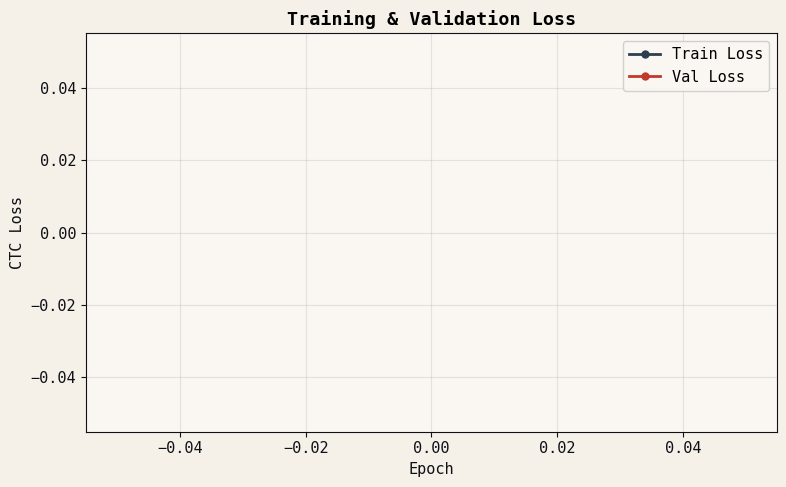

Saved: c:\Users\Charm\OneDrive\Desktop\projects\MessyWriting\web\static\plots/loss.png


In [37]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epochs, history["train_loss"], "o-", color="#2c3e50", linewidth=2, markersize=5, label="Train Loss")
ax.plot(epochs, history["val_loss"], "o-", color="#c0392b", linewidth=2, markersize=5, label="Val Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("CTC Loss")
ax.set_title("Training & Validation Loss", fontweight="bold")
ax.legend(framealpha=0.9)
ax.grid(True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "loss.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/loss.png")

## Plot 2 — Word-Level Accuracy

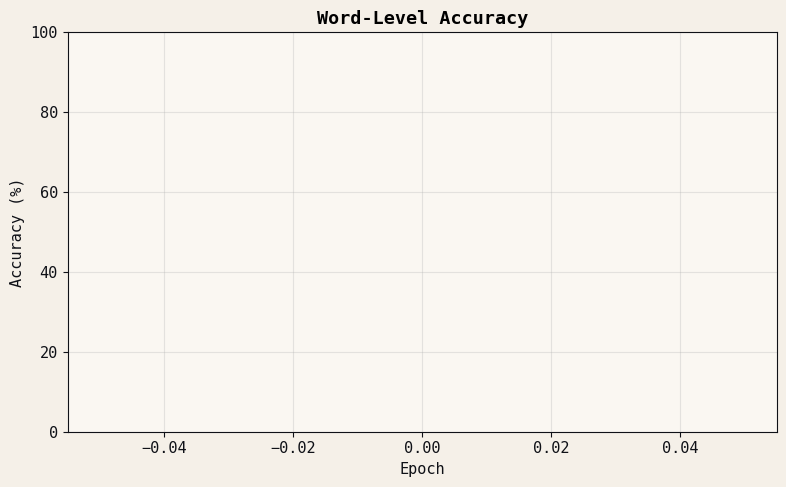

Saved: c:\Users\Charm\OneDrive\Desktop\projects\MessyWriting\web\static\plots/accuracy.png


In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epochs, history["val_accuracy"], "o-", color="#27ae60", linewidth=2, markersize=5)
ax.fill_between(epochs, history["val_accuracy"], alpha=0.15, color="#27ae60")

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Word-Level Accuracy", fontweight="bold")
ax.set_ylim(0, 100)
ax.grid(True)

# Annotate best accuracy
if history["val_accuracy"]:
    best_acc = max(history["val_accuracy"])
    best_ep = history["val_accuracy"].index(best_acc) + 1
    ax.annotate(f"Best: {best_acc:.1f}%",
                xy=(best_ep, best_acc), xytext=(best_ep + 2, best_acc - 10),
                arrowprops=dict(arrowstyle="->", color="#2c3e50"),
                fontsize=10, fontweight="bold")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/accuracy.png")

## Plot 3 — Character Error Rate (CER)

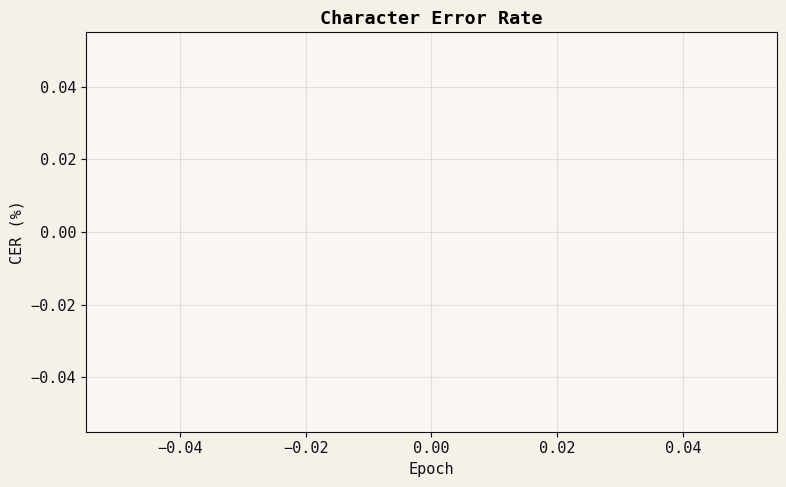

Saved: c:\Users\Charm\OneDrive\Desktop\projects\MessyWriting\web\static\plots/cer.png


In [39]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epochs, history["val_cer"], "o-", color="#c0392b", linewidth=2, markersize=5)
ax.fill_between(epochs, history["val_cer"], alpha=0.15, color="#c0392b")

ax.set_xlabel("Epoch")
ax.set_ylabel("CER (%)")
ax.set_title("Character Error Rate", fontweight="bold")
ax.grid(True)

# Annotate best CER
if history["val_cer"]:
    best_cer = min(history["val_cer"])
    best_ep = history["val_cer"].index(best_cer) + 1
    ax.annotate(f"Best: {best_cer:.1f}%",
                xy=(best_ep, best_cer), xytext=(best_ep + 2, best_cer + 5),
                arrowprops=dict(arrowstyle="->", color="#2c3e50"),
                fontsize=10, fontweight="bold")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "cer.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/cer.png")

## Summary Table

In [40]:
if history["train_loss"]:
    print(f"{'Metric':<25} {'Value':>10}")
    print("─" * 37)
    print(f"{'Total Epochs':<25} {len(epochs):>10}")
    print(f"{'Final Train Loss':<25} {history['train_loss'][-1]:>10.4f}")
    print(f"{'Final Val Loss':<25} {history['val_loss'][-1]:>10.4f}")
    print(f"{'Best Val Loss':<25} {min(history['val_loss']):>10.4f}")
    print(f"{'Best Accuracy':<25} {max(history['val_accuracy']):>9.1f}%")
    print(f"{'Best CER':<25} {min(history['val_cer']):>9.1f}%")
else:
    print("No training data available yet.")

No training data available yet.


## Plot 4 — t-SNE of Character Embeddings

Extract the BiLSTM hidden states at each timestep from validation samples, label each vector with its decoded character, then project to 2D with t-SNE. This is the sequence-model equivalent of a "decision boundary" — it shows how the model clusters characters in its internal feature space.

In [41]:
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from config import NUM_CLASSES, IDX2CHAR, TEST_DIR, BEST_WEIGHTS, FINAL_WEIGHTS
from core.model import ResNetCRNN
from pipeline.dataset import GNHKDataset, collate_fn

# ── Load model ──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetCRNN(NUM_CLASSES).to(device)

best_weights = PROJECT_ROOT / BEST_WEIGHTS
final_weights = PROJECT_ROOT / FINAL_WEIGHTS
weights = best_weights if best_weights.exists() else final_weights
if not weights.exists():
    raise FileNotFoundError(
        f"No checkpoint found. Expected one of: {best_weights} or {final_weights}"
    )

try:
    model.load_state_dict(torch.load(weights, map_location=device, weights_only=True))
except RuntimeError as e:
    raise RuntimeError(
        "Checkpoint does not match current model architecture. Retrain the model first."
    ) from e

model.eval()
print(f"Loaded model from {weights} on {device}")

# ── Extract BiLSTM embeddings ───────────────────────────────────────────────
test_dir = PROJECT_ROOT / TEST_DIR
val_set = GNHKDataset(str(test_dir))
val_loader = DataLoader(val_set, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=0)

all_embeddings = []  # (T, 512) feature vectors
all_chars = []       # character label for each vector
MAX_SAMPLES = 3000   # cap for speed

with torch.no_grad():
    for images, labels, label_lengths, ground_truths in val_loader:
        images = images.to(device)

        # Run through backbone to sequence features (B, T, 512)
        x = model.relu(model.bn1(model.conv1(images)))
        x = model.layer1(x)
        x = model.layer2(x)
        x = model.layer3(x)
        x = model.layer4(x)
        x = model.adaptive_pool(x)
        x = model.cnn_dropout(x)
        x = x.squeeze(2).permute(0, 2, 1)

        # BiLSTM + attention
        rnn_out, _ = model.rnn(x)
        rnn_out = model.rnn_dropout(rnn_out)
        rnn_out = model.attention(rnn_out)

        # Character predictions at each timestep
        logits = model.fc(rnn_out)    # (B, T, num_classes)
        preds = logits.argmax(2)      # (B, T)

        # Collect embeddings labeled by predicted character (skip blanks/repeats)
        for b in range(rnn_out.size(0)):
            prev = None
            for t in range(rnn_out.size(1)):
                char_idx = preds[b, t].item()
                if char_idx != 0 and char_idx != prev:
                    all_embeddings.append(rnn_out[b, t].cpu().numpy())
                    all_chars.append(IDX2CHAR.get(char_idx, "?"))
                prev = char_idx

        if len(all_embeddings) >= MAX_SAMPLES:
            break

all_embeddings = np.array(all_embeddings[:MAX_SAMPLES])
all_chars = all_chars[:MAX_SAMPLES]
print(f"Collected {len(all_embeddings)} character embeddings from {len(set(all_chars))} unique chars")

Loaded model from c:\Users\Charm\OneDrive\Desktop\projects\MessyWriting\checkpoints\crnn_gnhk_best.pth on cuda
Collected 3000 character embeddings from 72 unique chars


Running t-SNE (this may take a moment)...


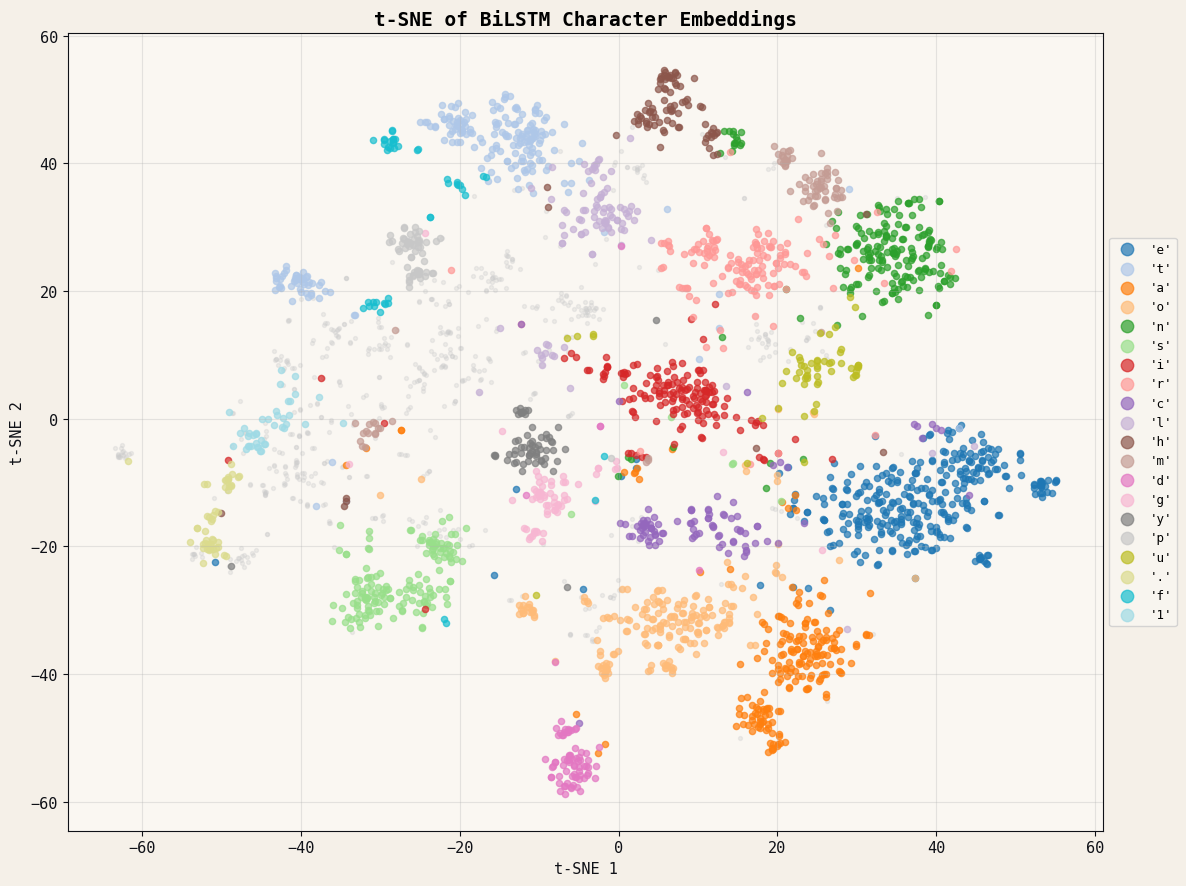

Saved: c:\Users\Charm\OneDrive\Desktop\projects\MessyWriting\web\static\plots/tsne_embeddings.png


In [42]:
# ── t-SNE projection ─────────────────────────────────────────────────────────
from collections import Counter

print("Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
embeddings_2d = tsne.fit_transform(all_embeddings)

# Pick top-N most frequent chars for a cleaner plot
char_counts = Counter(all_chars)
top_chars = [c for c, _ in char_counts.most_common(20)]

fig, ax = plt.subplots(figsize=(12, 9))

# Plot "other" characters in gray first
other_mask = np.array([c not in top_chars for c in all_chars])
if other_mask.any():
    ax.scatter(embeddings_2d[other_mask, 0], embeddings_2d[other_mask, 1],
               c="#cccccc", s=8, alpha=0.3, label="_other")

# Plot each top character with a unique color
cmap = plt.colormaps.get_cmap("tab20").resampled(len(top_chars))
for i, char in enumerate(top_chars):
    mask = np.array([c == char for c in all_chars])
    label = f"'{char}'" if char != " " else "(space)"
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
               c=[cmap(i)], s=20, alpha=0.7, label=label)

ax.set_title("t-SNE of BiLSTM Character Embeddings", fontweight="bold", fontsize=14)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9, ncol=1, markerscale=2)
ax.grid(True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "tsne_embeddings.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/tsne_embeddings.png")

## Plot 5 — PCA of Character Embeddings

PCA is faster than t-SNE and preserves global structure better. The first two principal components show the directions of maximum variance in the BiLSTM feature space.

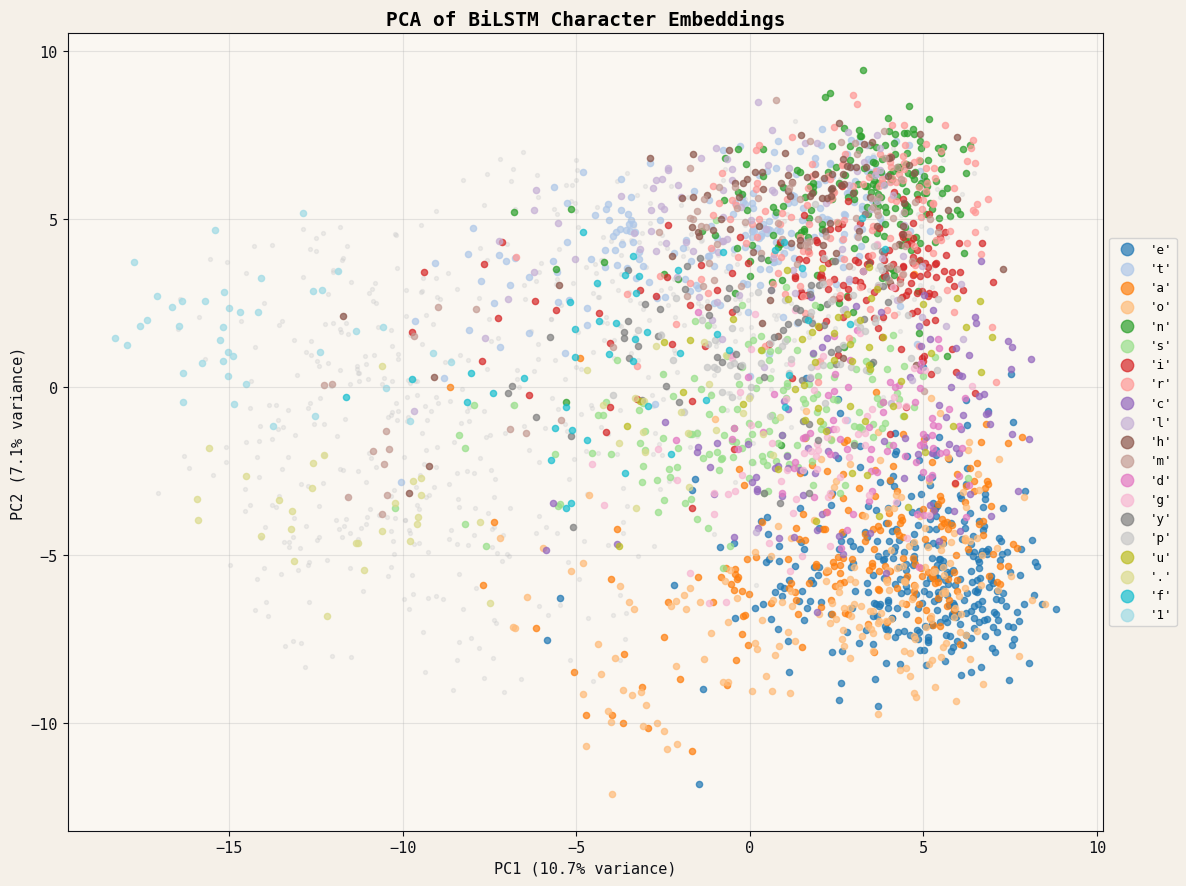

Saved: c:\Users\Charm\OneDrive\Desktop\projects\MessyWriting\web\static\plots/pca_embeddings.png
Top 2 PCs explain 17.8% of variance


In [43]:
# ── PCA projection ───────────────────────────────────────────────────────────
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(all_embeddings)

fig, ax = plt.subplots(figsize=(12, 9))

# Background: "other" characters in gray
if other_mask.any():
    ax.scatter(embeddings_pca[other_mask, 0], embeddings_pca[other_mask, 1],
               c="#cccccc", s=8, alpha=0.3)

# Top characters with color
cmap = plt.colormaps.get_cmap("tab20").resampled(len(top_chars))
for i, char in enumerate(top_chars):
    mask = np.array([c == char for c in all_chars])
    label = f"'{char}'" if char != " " else "(space)"
    ax.scatter(embeddings_pca[mask, 0], embeddings_pca[mask, 1],
               c=[cmap(i)], s=20, alpha=0.7, label=label)

var_explained = pca.explained_variance_ratio_ * 100
ax.set_title("PCA of BiLSTM Character Embeddings", fontweight="bold", fontsize=14)
ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9, ncol=1, markerscale=2)
ax.grid(True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "pca_embeddings.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/pca_embeddings.png")
print(f"Top 2 PCs explain {var_explained[:2].sum():.1f}% of variance")

## Plot 6 — Character Confusion Matrix

Aligns predicted and ground-truth characters using Levenshtein alignment, then builds a confusion matrix showing which characters are most commonly mistaken for each other. Focuses on the top 30 most frequent characters for readability.

In [44]:
from collections import Counter
from sklearn.metrics import confusion_matrix
import torch
from torch.utils.data import DataLoader
from core.decoding import ctc_greedy_decode_batch

# ── Collect character-level predictions vs ground truth ──────────────────────
def align_chars(pred, target):
    """Align predicted and target strings using Levenshtein DP to get
    character-level (pred_char, true_char) pairs including substitutions."""
    n, m = len(target), len(pred)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if target[i - 1] == pred[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(dp[i - 1][j - 1], dp[i - 1][j], dp[i][j - 1])

    # Backtrack to get aligned pairs
    pairs = []
    i, j = n, m
    while i > 0 or j > 0:
        if i > 0 and j > 0 and (target[i - 1] == pred[j - 1] or dp[i][j] == dp[i - 1][j - 1] + 1):
            pairs.append((target[i - 1], pred[j - 1]))  # match or substitution
            i -= 1
            j -= 1
        elif i > 0 and dp[i][j] == dp[i - 1][j] + 1:
            pairs.append((target[i - 1], "∅"))  # deletion
            i -= 1
        else:
            pairs.append(("∅", pred[j - 1]))  # insertion
            j -= 1
    return list(reversed(pairs))

# Decode predictions on validation set
pred_chars_all = []
true_chars_all = []

val_loader2 = DataLoader(val_set, batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0)
MAX_WORDS = 2000
word_count = 0

with torch.no_grad():
    for images, labels, label_lengths, ground_truths in val_loader2:
        images = images.to(device)
        outputs = model(images)
        decoded = ctc_greedy_decode_batch(outputs)

        for pred_text, gt_text in zip(decoded, ground_truths):
            for true_c, pred_c in align_chars(pred_text, gt_text):
                if true_c != "∅" and pred_c != "∅":  # only substitutions/matches
                    pred_chars_all.append(pred_c)
                    true_chars_all.append(true_c)
            word_count += 1

        if word_count >= MAX_WORDS:
            break

print(f"Aligned {len(true_chars_all)} character pairs from {word_count} words")

Aligned 8804 character pairs from 2016 words


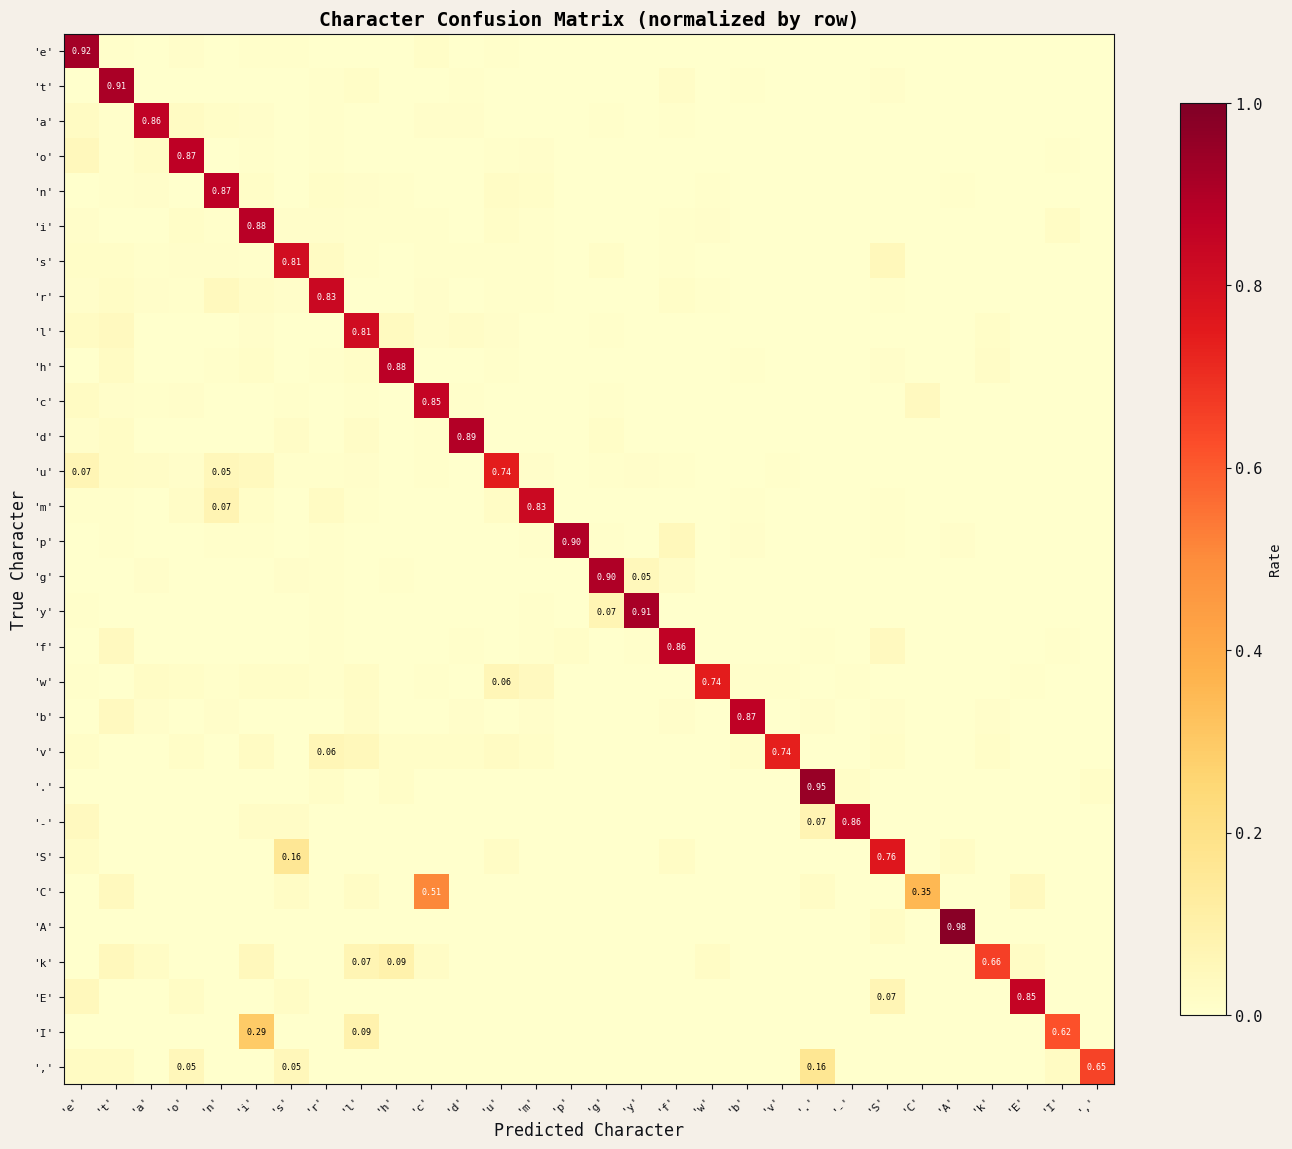

Saved: c:\Users\Charm\OneDrive\Desktop\projects\MessyWriting\web\static\plots/confusion_matrix.png


In [46]:
# ── Build and plot confusion matrix (top 30 chars) ──────────────────────────
if not true_chars_all or not pred_chars_all:
    raise RuntimeError("No aligned character data found. Run the previous confusion-data cell first.")

char_freq = Counter(true_chars_all)
top_30 = [c for c, _ in char_freq.most_common(30)]

# Filter to only top-30 characters
mask = [(t in top_30 and p in top_30) for t, p in zip(true_chars_all, pred_chars_all)]
filtered_true = [t for t, m in zip(true_chars_all, mask) if m]
filtered_pred = [p for p, m in zip(pred_chars_all, mask) if m]

cm = confusion_matrix(filtered_true, filtered_pred, labels=top_30)

# Normalize by row (true label count) to show error rates
cm_norm = cm.astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm_norm / row_sums

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm, cmap="YlOrRd", vmin=0, vmax=1)

# Labels
display_labels = [f"'{c}'" if c != " " else "sp" for c in top_30]
ax.set_xticks(range(len(top_30)))
ax.set_yticks(range(len(top_30)))
ax.set_xticklabels(display_labels, fontsize=8, rotation=45, ha="right")
ax.set_yticklabels(display_labels, fontsize=8)

ax.set_xlabel("Predicted Character", fontsize=12)
ax.set_ylabel("True Character", fontsize=12)
ax.set_title("Character Confusion Matrix (normalized by row)", fontweight="bold", fontsize=14)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Rate", fontsize=10)

# Annotate cells with values > 0.05 (to avoid clutter)
for i in range(len(top_30)):
    for j in range(len(top_30)):
        val = cm_norm[i, j]
        if val > 0.05:
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=color)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/confusion_matrix.png")

## Embedding on a Website

All plots are saved to `static/plots/`:

```
static/plots/
├── loss.png
├── accuracy.png
├── cer.png
├── tsne_embeddings.png
├── pca_embeddings.png
└── confusion_matrix.png
```

Use them in HTML:

```html
<img src="/static/plots/loss.png" alt="Training Loss" />
<img src="/static/plots/accuracy.png" alt="Word Accuracy" />
<img src="/static/plots/cer.png" alt="Character Error Rate" />
<img src="/static/plots/tsne_embeddings.png" alt="t-SNE Character Embeddings" />
<img src="/static/plots/pca_embeddings.png" alt="PCA Character Embeddings" />
<img src="/static/plots/confusion_matrix.png" alt="Confusion Matrix" />
```

Flask automatically serves files from the `static/` directory.